In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../data/criteo_ctr_drop_dataset.csv")

In [10]:
df

,date,user_id,country,device,browser,campaign,impressions,clicks,page_load_time,purchases,revenue
0,2026-06-07,1,USA,Mobile,Firefox,Fashion,18,0,0.952728,0,0.0
1,2026-06-20,2,USA,Mobile,Chrome,Sports,10,1,1.323906,0,0.0
2,2026-06-29,3,USA,Desktop,Chrome,Electronics,13,1,1.056189,0,0.0
3,2026-06-15,4,USA,Desktop,Chrome,Fashion,7,0,1.093450,0,0.0
4,2026-06-11,5,UK,Mobile,Safari,Electronics,11,0,1.253594,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
99995,2026-06-23,99996,USA,Desktop,Safari,Sports,17,1,1.024163,0,0.0
99996,2026-06-29,99997,UK,Desktop,Chrome,Sports,9,0,1.383788,0,0.0
99997,2026-06-21,99998,Germany,Mobile,Firefox,Electronics,5,0,1.405824,0,0.0
99998,2026-06-29,99999,Germany,Mobile,Chrome,Travel,16,0,0.964657,0,0.0


In [12]:
df.head()

,date,user_id,country,device,browser,campaign,impressions,clicks,page_load_time,purchases,revenue
0,2026-06-07,1,USA,Mobile,Firefox,Fashion,18,0,0.952728,0,0.0
1,2026-06-20,2,USA,Mobile,Chrome,Sports,10,1,1.323906,0,0.0
2,2026-06-29,3,USA,Desktop,Chrome,Electronics,13,1,1.056189,0,0.0
3,2026-06-15,4,USA,Desktop,Chrome,Fashion,7,0,1.093450,0,0.0
4,2026-06-11,5,UK,Mobile,Safari,Electronics,11,0,1.253594,0,0.0


In [14]:
df.shape

(100000, 11)

In [15]:
df['date']=pd.to_datetime(df['date'])

In [16]:
df.head()

,date,user_id,country,device,browser,campaign,impressions,clicks,page_load_time,purchases,revenue
0,2026-06-07,1,USA,Mobile,Firefox,Fashion,18,0,0.952728,0,0.0
1,2026-06-20,2,USA,Mobile,Chrome,Sports,10,1,1.323906,0,0.0
2,2026-06-29,3,USA,Desktop,Chrome,Electronics,13,1,1.056189,0,0.0
3,2026-06-15,4,USA,Desktop,Chrome,Fashion,7,0,1.093450,0,0.0
4,2026-06-11,5,UK,Mobile,Safari,Electronics,11,0,1.253594,0,0.0


In [20]:
df['ctr']=df['clicks']/df['impressions']

In [22]:
df[['clicks','ctr','impressions']].head()

,clicks,ctr,impressions
0,0,0.000000,18
1,1,0.100000,10
2,1,0.076923,13
3,0,0.000000,7
4,0,0.000000,11


In [23]:
df.head()

,date,user_id,country,device,browser,campaign,impressions,clicks,page_load_time,purchases,revenue,ctr
0,2026-06-07,1,USA,Mobile,Firefox,Fashion,18,0,0.952728,0,0.0,0.000000
1,2026-06-20,2,USA,Mobile,Chrome,Sports,10,1,1.323906,0,0.0,0.100000
2,2026-06-29,3,USA,Desktop,Chrome,Electronics,13,1,1.056189,0,0.0,0.076923
3,2026-06-15,4,USA,Desktop,Chrome,Fashion,7,0,1.093450,0,0.0,0.000000
4,2026-06-11,5,UK,Mobile,Safari,Electronics,11,0,1.253594,0,0.0,0.000000


In [24]:
daily_ctr= df.groupby('date').agg({'clicks':'sum','impressions':'sum'})

In [26]:
daily_ctr['ctr']=daily_ctr['clicks']/daily_ctr['impressions']

In [28]:
daily_ctr.head()

,clicks,impressions,ctr
date,,,
2026-06-01,1916,39897,0.048024
2026-06-02,2091,41575,0.050295
2026-06-03,2076,41121,0.050485
2026-06-04,2102,41924,0.050138
2026-06-05,1939,41002,0.047290


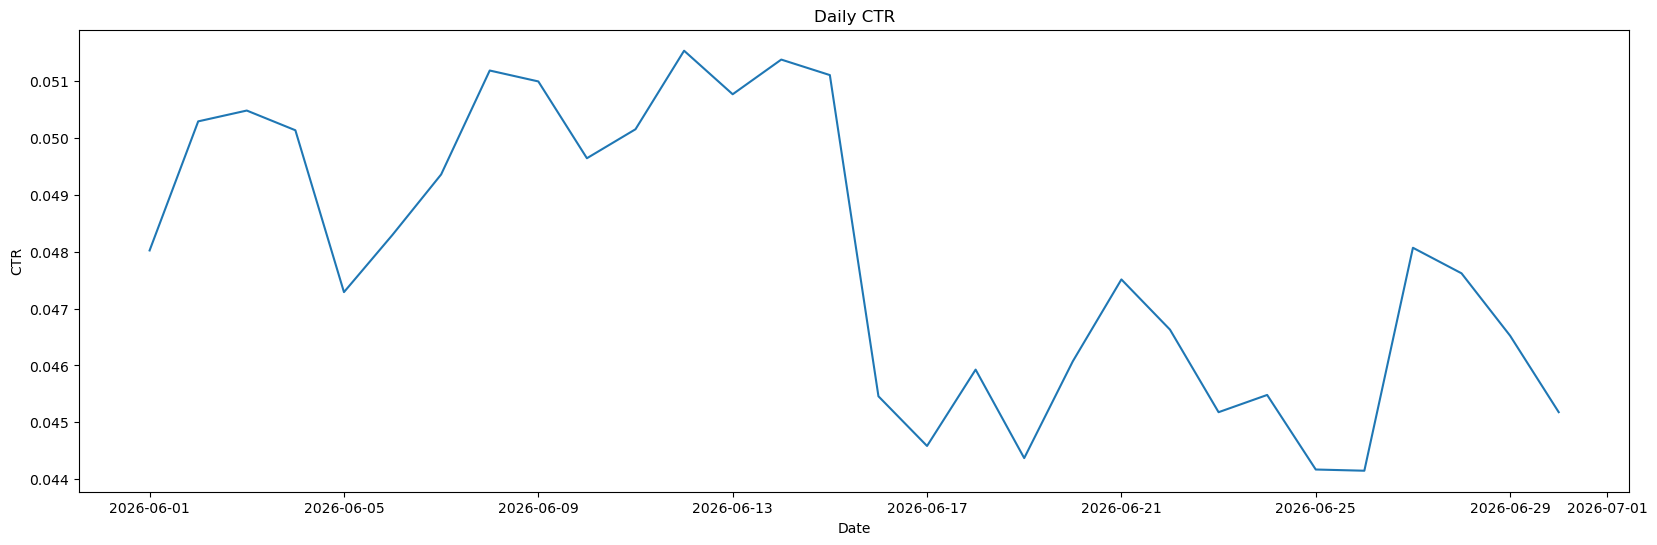

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,6))

plt.plot(
    daily_ctr.index,
    daily_ctr['ctr']
)
plt.xlabel('Date')
plt.ylabel('CTR')
plt.title('Daily CTR')

plt.show()